# 01. Data Audit

This notebook performs the initial audit of the competition dataset. The goal is to verify dataset integrity, summarize its structure, and identify potential data quality issues before any preprocessing or model development.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt

## Environment Setup

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root resolved successfully.")

Project root resolved successfully.


In [3]:
from src.churn_ml.data import (
    audit_dataframe,
    compare_feature_distributions,
    load_competition_data,
    summarize_dataframe,
)
from src.churn_ml.experiment import Experiment

## Dataset Loading

In [4]:
data = load_competition_data(
    train_path=PROJECT_ROOT / "data/raw/final_proj_data.csv",
    test_path=PROJECT_ROOT / "data/raw/final_proj_test.csv",
    sample_submission_path=(
        PROJECT_ROOT / "data/raw/final_proj_sample_submission.csv"
    ),
)

print("Train:", data.train.shape)
print("Test:", data.test.shape)
print("Sample submission:", data.sample_submission.shape)

Train: (10000, 231)
Test: (2500, 230)
Sample submission: (2500, 2)


## Experiment Initialization

In [5]:
experiment = Experiment(
    name="eda_001_initial_data_audit",
    model_type="eda",
    description="Initial audit of the training and test datasets",
    notes=(
        "Baseline data profile created before preprocessing, "
        "feature engineering, and model training"
    ),
    seed=42,
    train_path=PROJECT_ROOT / "data/raw/final_proj_data.csv",
    test_path=PROJECT_ROOT / "data/raw/final_proj_test.csv",
)

experiment.summary()

{'run_id': '20260722_213308_eda_001_initial_data_audit',
 'name': 'eda_001_initial_data_audit',
 'model_type': 'eda',
 'status': 'running',
 'artifact_path': 'artifacts\\experiments\\20260722_213308_eda_001_initial_data_audit'}

## Dataset Summary

In [6]:
test_audit = audit_dataframe(data.test)
train_audit = audit_dataframe(data.X)

train_summary = summarize_dataframe(data.train)
test_summary = summarize_dataframe(data.test)

summary = {
    "train": train_summary,
    "test": test_summary,
    "target": {
        "name": data.y.name,
        "n_classes": int(data.y.nunique()),
        "class_counts": {
            str(key): int(value)
            for key, value in data.y.value_counts().sort_index().items()
        },
        "class_rates": {
            str(key): float(value)
            for key, value in data.y.value_counts(
                normalize=True
            ).sort_index().items()
        },
    },
}

summary

{'train': {'n_rows': 10000,
  'n_columns': 231,
  'duplicate_rows': 0,
  'duplicate_rate': 0.0,
  'total_missing': 1603449,
  'columns_with_missing': 209,
  'constant_columns': 25},
 'test': {'n_rows': 2500,
  'n_columns': 230,
  'duplicate_rows': 0,
  'duplicate_rate': 0.0,
  'total_missing': 400991,
  'columns_with_missing': 209,
  'constant_columns': 31},
 'target': {'name': 'y',
  'n_classes': 2,
  'class_counts': {'0': 8695, '1': 1305},
  'class_rates': {'0': 0.8695, '1': 0.1305}}}

### Key Findings

- The training dataset contains **10,000 samples** and **230 input features**, while the test dataset contains **2,500 samples** with the same feature set (excluding the target).
- No duplicate rows were detected in either dataset, so duplicate removal is not required.
- Missing values are widespread: **209 out of 230 features** contain at least one missing value in both datasets.
- The datasets contain a substantial amount of missing data (**1.6 million** missing values in the training set), indicating that missing value handling will be an important part of the preprocessing pipeline.
- The training set contains **25 constant features**, while the test set contains **31**. This discrepancy suggests that some features are constant only in the test data and should be investigated before feature selection.
- The target variable is **highly imbalanced**:
  - Class 0: **86.95%**
  - Class 1: **13.05%**
- Because of this imbalance, evaluation should focus on metrics such as **ROC-AUC**, **PR-AUC**, or **F1-score**, rather than overall accuracy alone.

## Train/Test Consistency Checks

In [7]:
train_constants = set(
    train_audit.loc[
        train_audit["is_constant"],
        "column",
    ]
)

test_constants = set(
    test_audit.loc[
        test_audit["is_constant"],
        "column",
    ]
)

print("Train:", len(train_constants))
print("Test :", len(test_constants))

Train: 25
Test : 31


In [8]:
only_in_train = sorted(train_constants - test_constants)
only_in_test = sorted(test_constants - train_constants)

print("Only in train:", only_in_train)
print("Only in test :", only_in_test)

Only in train: []
Only in test : ['Var201', 'Var27', 'Var29', 'Var49', 'Var67', 'Var90']


In [9]:
constant_feature_summary, constant_feature_distributions = (
    compare_feature_distributions(
        train=data.X,
        test=data.test,
        columns=only_in_test,
    )
)

display(constant_feature_summary)
display(constant_feature_distributions)

,column,dataset,n_rows,n_missing,missing_rate,n_unique
0,Var201,train,10000,7467,0.7467,2
1,Var201,test,2500,1872,0.7488,1
2,Var27,train,10000,9759,0.9759,2
3,Var27,test,2500,2439,0.9756,1
4,Var29,train,10000,9867,0.9867,2
5,Var29,test,2500,2462,0.9848,1
6,Var49,train,10000,9734,0.9734,2
7,Var49,test,2500,2422,0.9688,1
8,Var67,train,10000,9759,0.9759,2
9,Var67,test,2500,2439,0.9756,1


,column,dataset,value,count,rate
0,Var201,train,<MISSING>,7467,0.7467
1,Var201,train,smXZ,2531,0.2531
2,Var201,train,6dX3,2,0.0002
3,Var201,test,<MISSING>,1872,0.7488
4,Var201,test,smXZ,628,0.2512
5,Var27,train,<MISSING>,9759,0.9759
6,Var27,train,0.0,239,0.0239
7,Var27,train,2.0,2,0.0002
8,Var27,test,<MISSING>,2439,0.9756
9,Var27,test,0.0,61,0.0244


In [10]:
experiment.save_dataframe(
    constant_feature_summary,
    "constant_feature_comparison.csv",
)

experiment.save_dataframe(
    constant_feature_distributions,
    "constant_feature_distributions.csv",
)

WindowsPath('artifacts/experiments/20260722_213308_eda_001_initial_data_audit/reports/constant_feature_distributions.csv')

### Key Findings

- Six features are constant only in the test dataset.
- The discrepancy is caused by extremely rare values that appear only one to three times in the training set and are absent from the smaller test set.
- No schema mismatch was found.
- For these six features, the observed train/test difference is explained by ultra-rare values that are absent from the smaller test sample.
- These features should not be removed solely because they are constant in the test set; their usefulness should be evaluated during model development.

## Feature Audit

In [11]:
train_audit = audit_dataframe(data.X)
test_audit = audit_dataframe(data.test)

display(
    train_audit.sort_values(
        ["missing_rate", "n_unique"],
        ascending=[False, True],
    )
)

,column,dtype,n_rows,n_missing,missing_rate,n_unique,unique_rate,is_constant,is_all_missing,is_numeric,is_integer,is_float,is_bool,is_object,is_category
0,Var8,float64,10000,10000,1.0,0,0.0000,True,True,True,False,True,False,False,False
1,Var15,float64,10000,10000,1.0,0,0.0000,True,True,True,False,True,False,False,False
2,Var20,float64,10000,10000,1.0,0,0.0000,True,True,True,False,True,False,False,False
3,Var31,float64,10000,10000,1.0,0,0.0000,True,True,True,False,True,False,False,False
4,Var32,float64,10000,10000,1.0,0,0.0000,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,Var220,object,10000,0,0.0,2100,0.2100,False,False,False,False,False,False,True,False
226,Var222,object,10000,0,0.0,2100,0.2100,False,False,False,False,False,False,True,False
227,Var202,object,10000,0,0.0,3802,0.3802,False,False,False,False,False,False,True,False
228,Var57,float64,10000,0,0.0,8602,0.8602,False,False,True,False,True,False,False,False


In [12]:
feature_summary = pd.DataFrame(
    {
        "Metric": [
            "Total features",
            "Numeric features",
            "Object features",
            "Features with missing values",
            "All missing features",
            "Constant features",
        ],
        "Value": [
            len(train_audit),
            train_audit["is_numeric"].sum(),
            train_audit["is_object"].sum(),
            (train_audit["n_missing"] > 0).sum(),
            train_audit["is_all_missing"].sum(),
            train_audit["is_constant"].sum(),
        ],
    }
)

display(feature_summary)

,Metric,Value
0,Total features,230
1,Numeric features,192
2,Object features,38
3,Features with missing values,209
4,All missing features,18
5,Constant features,25


### Key Findings

- Eighteen features contain only missing values and therefore provide no information.
- Twenty-five features are constant in the training dataset, including the fully missing features.
- Several features are extremely sparse (more than 99% missing) while still containing multiple unique values.
- Sparse features should not be discarded solely because of their missing rate, as they may still carry predictive information.
- The audit results will guide the preprocessing strategy, including feature removal, missing value handling, and feature engineering.

## Target Distribution

,class,count,rate
0,0,8695,0.8695
1,1,1305,0.1305


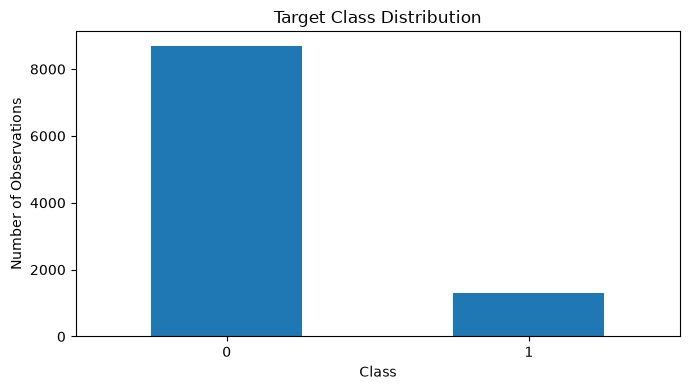

In [13]:
class_distribution = (
    data.y
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["rate"] = (
    class_distribution["count"] / len(data.y)
)

display(class_distribution)

ax = class_distribution.plot(
    x="class",
    y="count",
    kind="bar",
    legend=False,
    figsize=(7, 4),
)

ax.set_title("Target Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Observations")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Key Findings

## Save Audit Reports

In [14]:
experiment.save_json(summary, "data_summary.json")
experiment.save_dataframe(train_audit, "train_audit.csv")
experiment.save_dataframe(test_audit, "test_audit.csv")
experiment.save_dataframe(
    class_distribution,
    "class_distribution.csv",
)

experiment.complete(
    metrics={
        "n_train_rows": len(data.train),
        "n_test_rows": len(data.test),
        "n_features": data.X.shape[1],
        "n_constant_features": int(
            train_audit["is_constant"].sum()
        ),
        "n_all_missing_features": int(
            train_audit["is_all_missing"].sum()
        ),
        "target_positive_rate": float(data.y.mean()),
    }
)

experiment.summary()

{'run_id': '20260722_213308_eda_001_initial_data_audit',
 'name': 'eda_001_initial_data_audit',
 'model_type': 'eda',
 'status': 'completed',
 'artifact_path': 'artifacts\\experiments\\20260722_213308_eda_001_initial_data_audit'}

# Audit Summary

The initial audit confirms that the dataset is internally consistent and suitable for model development.

Main findings:

- No duplicate rows were detected.
- Missing values are widespread and require dedicated handling.
- Twenty-five features are constant in the training set.
- The target variable is highly imbalanced (~87% vs ~13%).
- Minor train/test differences in constant features are explained by extremely rare values and do not indicate a schema mismatch.

The next step is to perform a more detailed exploratory data analysis (EDA) to better understand feature distributions, missing value patterns, and relationships with the target variable.